MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms. As new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike.

In this competition, your goal is to correctly identify digits from a dataset of tens of thousands of handwritten images. We’ve curated a set of tutorial-style kernels which cover everything from regression to neural networks. We encourage you to experiment with different algorithms to learn first-hand what works well and how techniques compare.

Import

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

Load and read datasets

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [3]:
# load datasets
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')
sample = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')

In [4]:
train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
sample

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
27995,27996,0
27996,27997,0
27997,27998,0
27998,27999,0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


Check for null 

In [9]:
train.isnull().sum().sum(), test.isnull().sum().sum()

(0, 0)

Analyse label

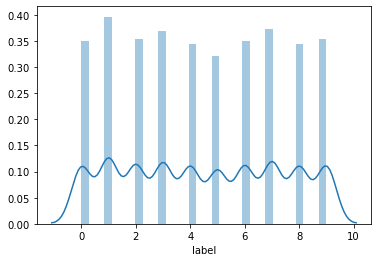

In [10]:
sns.distplot(train['label'])

Define X, y and X_test

In [11]:
ImageId = test.index + 1

y = train.iloc[:,0]
X = train.iloc[::,1:]
X_test = test

In [12]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [13]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
X_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Scaler

In [15]:
#the MNIST dataset has images with pixel values in the range [0, 255]
X = X / 255
X_test = X_test / 255

In [16]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Split X for training and validating

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape


((37800, 784), (4200, 784), (37800,), (4200,), (28000, 784))

Define model - Keras Sequential

In [19]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

Predict on validation set

In [20]:
pred = model(X_train[:1]).numpy()
pred

array([[-0.15062906, -0.42196503,  0.14992788,  0.5009782 ,  0.0297705 ,
        -0.47107083, -0.43561333,  0.37428132,  0.04031128, -0.08617139]],
      dtype=float32)

In [21]:
tf.nn.softmax(pred).numpy()

array([[0.08565737, 0.06530178, 0.11568978, 0.16434412, 0.10259147,
        0.06217255, 0.06441658, 0.14478728, 0.10367858, 0.09136048]],
      dtype=float32)

In [22]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [23]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [24]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.3477 - accuracy: 0.8974
Epoch 2/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.1691 - accuracy: 0.9496
Epoch 3/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.1250 - accuracy: 0.9619
Epoch 4/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.1014 - accuracy: 0.9693
Epoch 5/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.0851 - accuracy: 0.9741
Epoch 6/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.0714 - accuracy: 0.9776
Epoch 7/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.0611 - accuracy: 0.9812
Epoch 8/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.0549 - accuracy: 0.9824
Epoch 9/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.0512 - accuracy: 0.9836
Epoch 10/50
1182/1182 [==============================] - 2s 2ms/step - loss: 0.044

In [25]:
model.evaluate(X_val,  y_val, verbose=2)

132/132 - 0s - loss: 0.1331 - accuracy: 0.9750


[0.13309946656227112, 0.9750000238418579]

In [26]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [27]:
probability_model(X_val[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[4.9345310e-13, 1.8403419e-11, 1.6870231e-06, 8.7346869e-10,
        5.1311921e-19, 3.5333888e-18, 1.6554038e-13, 7.3609916e-16,
        9.9999833e-01, 4.8704831e-15],
       [2.0144945e-17, 9.9999845e-01, 2.6415378e-12, 1.9022019e-14,
        6.2962213e-10, 3.8169012e-13, 3.6433615e-14, 1.5664676e-06,
        1.2190207e-08, 2.1917523e-14],
       [3.5989313e-20, 8.8751939e-18, 2.3631220e-18, 2.3146385e-09,
        6.7762512e-10, 8.5812607e-13, 1.1636663e-25, 2.7077309e-07,
        2.4496393e-11, 9.9999976e-01],
       [2.9783665e-27, 1.2069800e-31, 1.9100649e-29, 2.1705882e-14,
        6.0961368e-15, 1.4078319e-18, 0.0000000e+00, 1.4504054e-04,
        2.8797704e-19, 9.9985492e-01],
       [3.1193519e-18, 1.6539256e-10, 5.7561955e-11, 2.9020047e-10,
        8.7827368e-20, 2.5674093e-16, 4.6193985e-14, 4.0795249e-20,
        1.0000000e+00, 4.3478757e-17]], dtype=float32)>

In [28]:
y_pred = model.predict(X_val)
y_pred

array([[-11.743333  ,  -8.124469  ,   3.3014698 , ..., -18.25115   ,
         16.594013  , -16.361565  ],
       [-24.603794  ,  13.839784  , -12.819875  , ...,   0.47309756,
         -4.3828473 , -17.611708  ],
       [-28.974003  , -23.466202  , -24.789484  , ...,   0.67507976,
         -8.635429  ,  15.797065  ],
       ...,
       [-28.181314  , -31.452286  , -11.959848  , ...,  26.673677  ,
        -32.108624  ,  11.245183  ],
       [-25.00732   , -57.7257    , -13.0130005 , ...,  18.640715  ,
        -26.571384  ,   4.691271  ],
       [-33.26295   ,  -9.062417  , -14.296784  , ..., -36.31773   ,
         -9.222085  ,  -7.683888  ]], dtype=float32)

In [29]:
y_pred_final = []
for i in y_pred:
    y_pred_final.append(np.argmax(i))
    
y_pred_final

[8,
 1,
 9,
 9,
 8,
 6,
 2,
 2,
 7,
 1,
 6,
 3,
 1,
 2,
 7,
 4,
 3,
 3,
 6,
 4,
 9,
 5,
 2,
 6,
 0,
 0,
 0,
 8,
 6,
 3,
 6,
 6,
 1,
 9,
 8,
 6,
 7,
 3,
 6,
 1,
 9,
 7,
 9,
 6,
 8,
 3,
 4,
 2,
 7,
 8,
 4,
 3,
 3,
 7,
 1,
 2,
 6,
 2,
 9,
 6,
 6,
 0,
 4,
 8,
 5,
 8,
 4,
 3,
 9,
 3,
 9,
 7,
 2,
 8,
 1,
 6,
 3,
 7,
 0,
 3,
 1,
 7,
 6,
 7,
 6,
 1,
 9,
 5,
 3,
 6,
 9,
 3,
 7,
 6,
 6,
 5,
 2,
 9,
 3,
 5,
 4,
 6,
 0,
 4,
 1,
 1,
 1,
 6,
 8,
 9,
 1,
 1,
 4,
 7,
 1,
 0,
 3,
 6,
 9,
 8,
 1,
 3,
 7,
 3,
 9,
 6,
 5,
 7,
 1,
 0,
 6,
 5,
 6,
 4,
 2,
 0,
 9,
 9,
 9,
 4,
 2,
 3,
 6,
 4,
 0,
 9,
 9,
 1,
 7,
 7,
 1,
 6,
 8,
 1,
 7,
 6,
 6,
 5,
 7,
 9,
 9,
 0,
 7,
 9,
 9,
 1,
 3,
 6,
 5,
 8,
 7,
 1,
 6,
 7,
 0,
 9,
 3,
 0,
 8,
 6,
 0,
 1,
 9,
 7,
 2,
 3,
 7,
 2,
 6,
 6,
 4,
 8,
 9,
 6,
 0,
 7,
 4,
 5,
 5,
 6,
 3,
 1,
 5,
 3,
 7,
 9,
 9,
 0,
 7,
 4,
 7,
 5,
 1,
 1,
 0,
 2,
 5,
 3,
 8,
 1,
 3,
 9,
 3,
 6,
 7,
 3,
 1,
 3,
 4,
 4,
 0,
 2,
 7,
 1,
 4,
 2,
 1,
 0,
 5,
 3,
 9,
 1,
 7,
 6,
 5,
 1,
 0,
 5,
 7,
 9,


In [30]:
df = pd.DataFrame({'actual': y_val, 'predicted': y_pred_final})
df

,actual,predicted
5457,8,8
38509,1,1
25536,9,9
31803,9,9
39863,8,8
...,...,...
16041,4,4
4867,2,2
28123,7,7
3780,7,7


Predict on test set

In [31]:
prediction = model.predict(X_test)
prediction

array([[-2.2205299e+01, -4.6995430e+01,  2.3193151e+01, ...,
        -7.9344282e+00, -1.6463428e+01, -3.6906349e+01],
       [ 2.6724886e+01, -2.8069923e+01, -2.2403994e+00, ...,
        -2.4377602e+01, -3.1123590e+01, -2.5672380e+01],
       [-1.7690739e+01, -1.0706871e+01, -8.8370390e+00, ...,
        -4.5398221e+00, -3.4858706e+00,  7.3886509e+00],
       ...,
       [-4.2122871e+01, -1.0425752e+01, -1.4721721e+01, ...,
        -2.8304529e+01, -3.7664831e-02, -6.3371077e+00],
       [-1.9892925e+01, -3.6227669e+01, -2.1853886e+01, ...,
        -3.0946300e+00, -1.3946586e+01,  1.5829819e+01],
       [-2.8291767e+01, -2.6340853e+01,  1.8843582e+01, ...,
        -1.6214308e+01, -1.8207499e+01, -2.8576857e+01]], dtype=float32)

In [32]:
prediction_final = []
for i in prediction:
    prediction_final.append(np.argmax(i))
    
prediction_final

[2,
 0,
 9,
 9,
 3,
 7,
 0,
 3,
 0,
 3,
 5,
 7,
 4,
 0,
 4,
 3,
 3,
 1,
 9,
 0,
 9,
 1,
 1,
 5,
 7,
 4,
 2,
 7,
 4,
 7,
 7,
 5,
 4,
 2,
 6,
 2,
 5,
 5,
 1,
 6,
 7,
 7,
 4,
 9,
 8,
 7,
 8,
 2,
 6,
 7,
 6,
 8,
 8,
 3,
 8,
 2,
 1,
 2,
 2,
 0,
 4,
 1,
 7,
 0,
 0,
 0,
 1,
 9,
 0,
 1,
 6,
 5,
 8,
 8,
 2,
 8,
 8,
 9,
 2,
 3,
 5,
 9,
 1,
 0,
 9,
 2,
 4,
 3,
 6,
 7,
 2,
 0,
 6,
 6,
 1,
 4,
 3,
 9,
 7,
 4,
 0,
 9,
 2,
 0,
 7,
 3,
 0,
 5,
 0,
 8,
 0,
 0,
 4,
 7,
 1,
 7,
 1,
 1,
 3,
 3,
 3,
 7,
 2,
 8,
 6,
 3,
 8,
 7,
 8,
 4,
 3,
 5,
 6,
 0,
 0,
 0,
 3,
 1,
 3,
 6,
 4,
 3,
 4,
 5,
 5,
 8,
 7,
 7,
 2,
 8,
 4,
 3,
 5,
 6,
 5,
 3,
 7,
 5,
 7,
 8,
 3,
 0,
 4,
 5,
 1,
 2,
 7,
 6,
 3,
 0,
 2,
 7,
 8,
 6,
 1,
 3,
 7,
 4,
 1,
 2,
 4,
 8,
 5,
 2,
 4,
 9,
 2,
 1,
 6,
 0,
 6,
 1,
 4,
 9,
 6,
 0,
 9,
 7,
 6,
 9,
 1,
 9,
 0,
 9,
 9,
 0,
 8,
 4,
 6,
 2,
 0,
 9,
 3,
 6,
 3,
 2,
 1,
 6,
 3,
 4,
 2,
 3,
 1,
 2,
 2,
 0,
 4,
 6,
 1,
 0,
 0,
 4,
 9,
 1,
 7,
 3,
 2,
 3,
 8,
 6,
 8,
 6,
 2,
 8,
 5,
 5,
 4,
 8,
 3,
 5,


Prepare submission

In [33]:
sample.Label = prediction_final
sample.to_csv('submission.csv', index=False)
submission = pd.read_csv("submission.csv")
submission

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9
